# Kalman Filter State Estimation

A signal processing project demonstrating Kalman filtering for recovering hidden states from noisy measurements.

## Objective

The purpose of this project is to estimate the true state of a system when measurements are corrupted by noise.

The Kalman Filter combines model predictions and sensor measurements to produce an optimal estimate.

## Features

- State estimation
- Signal denoising
- Measurement fusion
- Uncertainty handling
- Mean Squared Error evaluation
- Visualisation

## Technologies

- Python
- NumPy
- Matplotlib

## Applications

- Financial Markets
- GPS Tracking
- Robotics
- Navigation Systems
- Sensor Fusion
- Environmental Monitoring

## Author

Parag Gupta

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

n = 100

t = np.arange(n)

true_signal = (
    50
    + 10*np.sin(t/10)
)

In [3]:
noise = np.random.normal(
    0,
    4,
    n
)

measurements = true_signal + noise

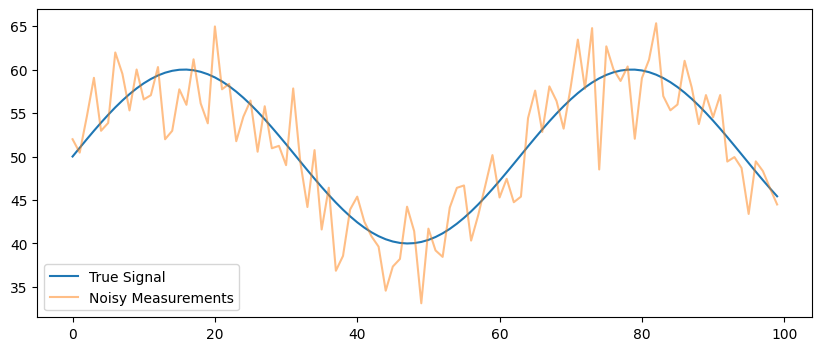

In [4]:
plt.figure(figsize=(10,4))

plt.plot(
    true_signal,
    label="True Signal"
)

plt.plot(
    measurements,
    alpha=0.5,
    label="Noisy Measurements"
)

plt.legend()

plt.show()

In [5]:
def kalman_filter(
    measurements,
    Q=1,
    R=16
):

    x_est = measurements[0]

    P = 1

    estimates = []

    for z in measurements:

        x_pred = x_est

        P_pred = P + Q

        K = P_pred / (P_pred + R)

        x_est = x_pred + K*(z - x_pred)

        P = (1-K)*P_pred

        estimates.append(x_est)

    return np.array(estimates)

In [6]:
filtered_signal = kalman_filter(
    measurements
)

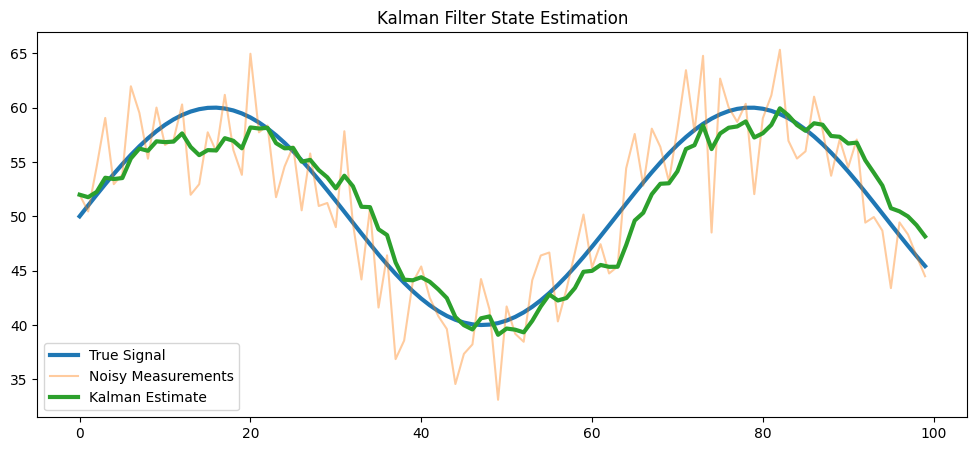

In [7]:
plt.figure(figsize=(12,5))

plt.plot(
    true_signal,
    linewidth=3,
    label="True Signal"
)

plt.plot(
    measurements,
    alpha=0.4,
    label="Noisy Measurements"
)

plt.plot(
    filtered_signal,
    linewidth=3,
    label="Kalman Estimate"
)

plt.legend()

plt.title(
    "Kalman Filter State Estimation"
)

plt.show()

In [8]:
mse_raw = np.mean(
    (measurements-true_signal)**2
)

mse_kf = np.mean(
    (filtered_signal-true_signal)**2
)

print(
    "Raw MSE:",
    round(mse_raw,2)
)

print(
    "Kalman MSE:",
    round(mse_kf,2)
)

Raw MSE: 13.24
Kalman MSE: 4.21
